
# Breast Cancer Histopathology Classification
**Dataset:** BreaKHis · **Task:** Benign vs Malignant + 8-subtype classification
**Notebook 1 of 4:** EDA & Data Pipeline

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter

# reproducibility
random.seed(42)
np.random.seed(42)

# working folders
os.makedirs('/kaggle/working/splits', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)

DATA_ROOT = DATA_ROOT = DATA_ROOT = '/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast'
print("Setup done.")

Setup done.


In [2]:
#code
#Cell 2 — scan all image paths into a dataframe
# BreaKHis folder structure:
import glob

records = []
for path in glob.glob(DATA_ROOT + '/**/*.png', recursive=True):
    parts = path.split('/')
    
    # skip non-image files
    if not any(m in parts for m in ['40X', '100X', '200X', '400X']):
        continue

    binary_name = 'Benign' if 'benign' in path.lower() else 'Malignant'
    binary_label = 0 if binary_name == 'Benign' else 1
    magnification = [p for p in parts if p in ['40X','100X','200X','400X']][0]
    mag_idx = parts.index(magnification)
    subtype = parts[mag_idx - 2]
    patient = parts[mag_idx - 1]

    records.append({
        'path':          path,
        'binary_label':  binary_label,
        'binary_name':   binary_name,
        'subtype':       subtype,
        'patient':       patient,
        'magnification': magnification,
    })

df = pd.DataFrame(records)
subtypes = sorted(df['subtype'].unique())
subtype2idx = {s: i for i, s in enumerate(subtypes)}
df['subtype_label'] = df['subtype'].map(subtype2idx)

print(f"Total images: {len(df)}")
print(f"Subtypes found: {subtypes}")
df.head()

Total images: 7909
Subtypes found: ['adenosis', 'ductal_carcinoma', 'fibroadenoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma', 'phyllodes_tumor', 'tubular_adenoma']


,path,binary_label,binary_name,subtype,patient,magnification,subtype_label
0,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,Benign,adenosis,SOB_B_A_14-29960CD,200X,0
1,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,Benign,adenosis,SOB_B_A_14-29960CD,200X,0
2,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,Benign,adenosis,SOB_B_A_14-29960CD,200X,0
3,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,Benign,adenosis,SOB_B_A_14-29960CD,200X,0
4,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,Benign,adenosis,SOB_B_A_14-29960CD,200X,0


## Dataset overview

The BreaKHis dataset contains **7,909 histopathology images** across 8 tumor subtypes, 
collected from 82 patients at 4 magnification levels (40X, 100X, 200X, 400X). 
Each image is an H&E stained slide patch at 700×460 pixels.

The 8 subtypes break down into two clinical categories:
- **Benign:** adenosis, fibroadenoma, phyllodes tumor, tubular adenoma
- **Malignant:** ductal carcinoma, lobular carcinoma, mucinous carcinoma, papillary carcinoma

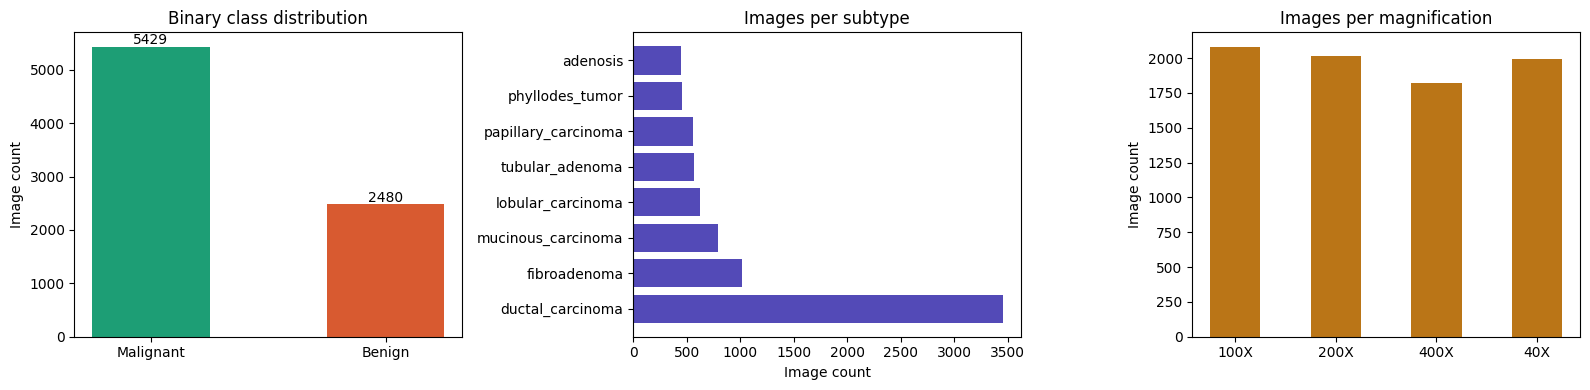

In [3]:
#code
#Cell 3 — class distribution charts
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Binary
counts = df['binary_name'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#1D9E75', '#D85A30'], width=0.5)
axes[0].set_title('Binary class distribution')
axes[0].set_ylabel('Image count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

# 2. Subtype
sub_counts = df['subtype'].value_counts()
axes[1].barh(sub_counts.index, sub_counts.values, color='#534AB7')
axes[1].set_title('Images per subtype')
axes[1].set_xlabel('Image count')

# 3. Magnification
mag_counts = df['magnification'].value_counts().sort_index()
axes[2].bar(mag_counts.index, mag_counts.values, color='#BA7517', width=0.5)
axes[2].set_title('Images per magnification')
axes[2].set_ylabel('Image count')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/class_distribution.png', dpi=150)
plt.show()

## Key findings — class distribution

**Binary imbalance:** The dataset is notably imbalanced — 5,429 malignant images (69%) 
vs 2,480 benign (31%). This is clinically realistic but means we must account for this 
imbalance during training, either through weighted loss or oversampling.

**Subtype imbalance:** Ductal carcinoma dominates the malignant class, followed by 
fibroadenoma among benign subtypes. Mucinous carcinoma has the fewest samples, 
which may affect per-class performance in the multi-class task.

**Magnification distribution:** 100X has the highest image count, followed by 40X — 
the magnification most commonly used by pathologists in clinical practice. 
This distribution is consistent with the original dataset design (Spanhol et al., 2016).

> **Implication for training:** We will use weighted CrossEntropy loss to handle the 
> malignant/benign imbalance, and report per-class F1 scores alongside overall accuracy.

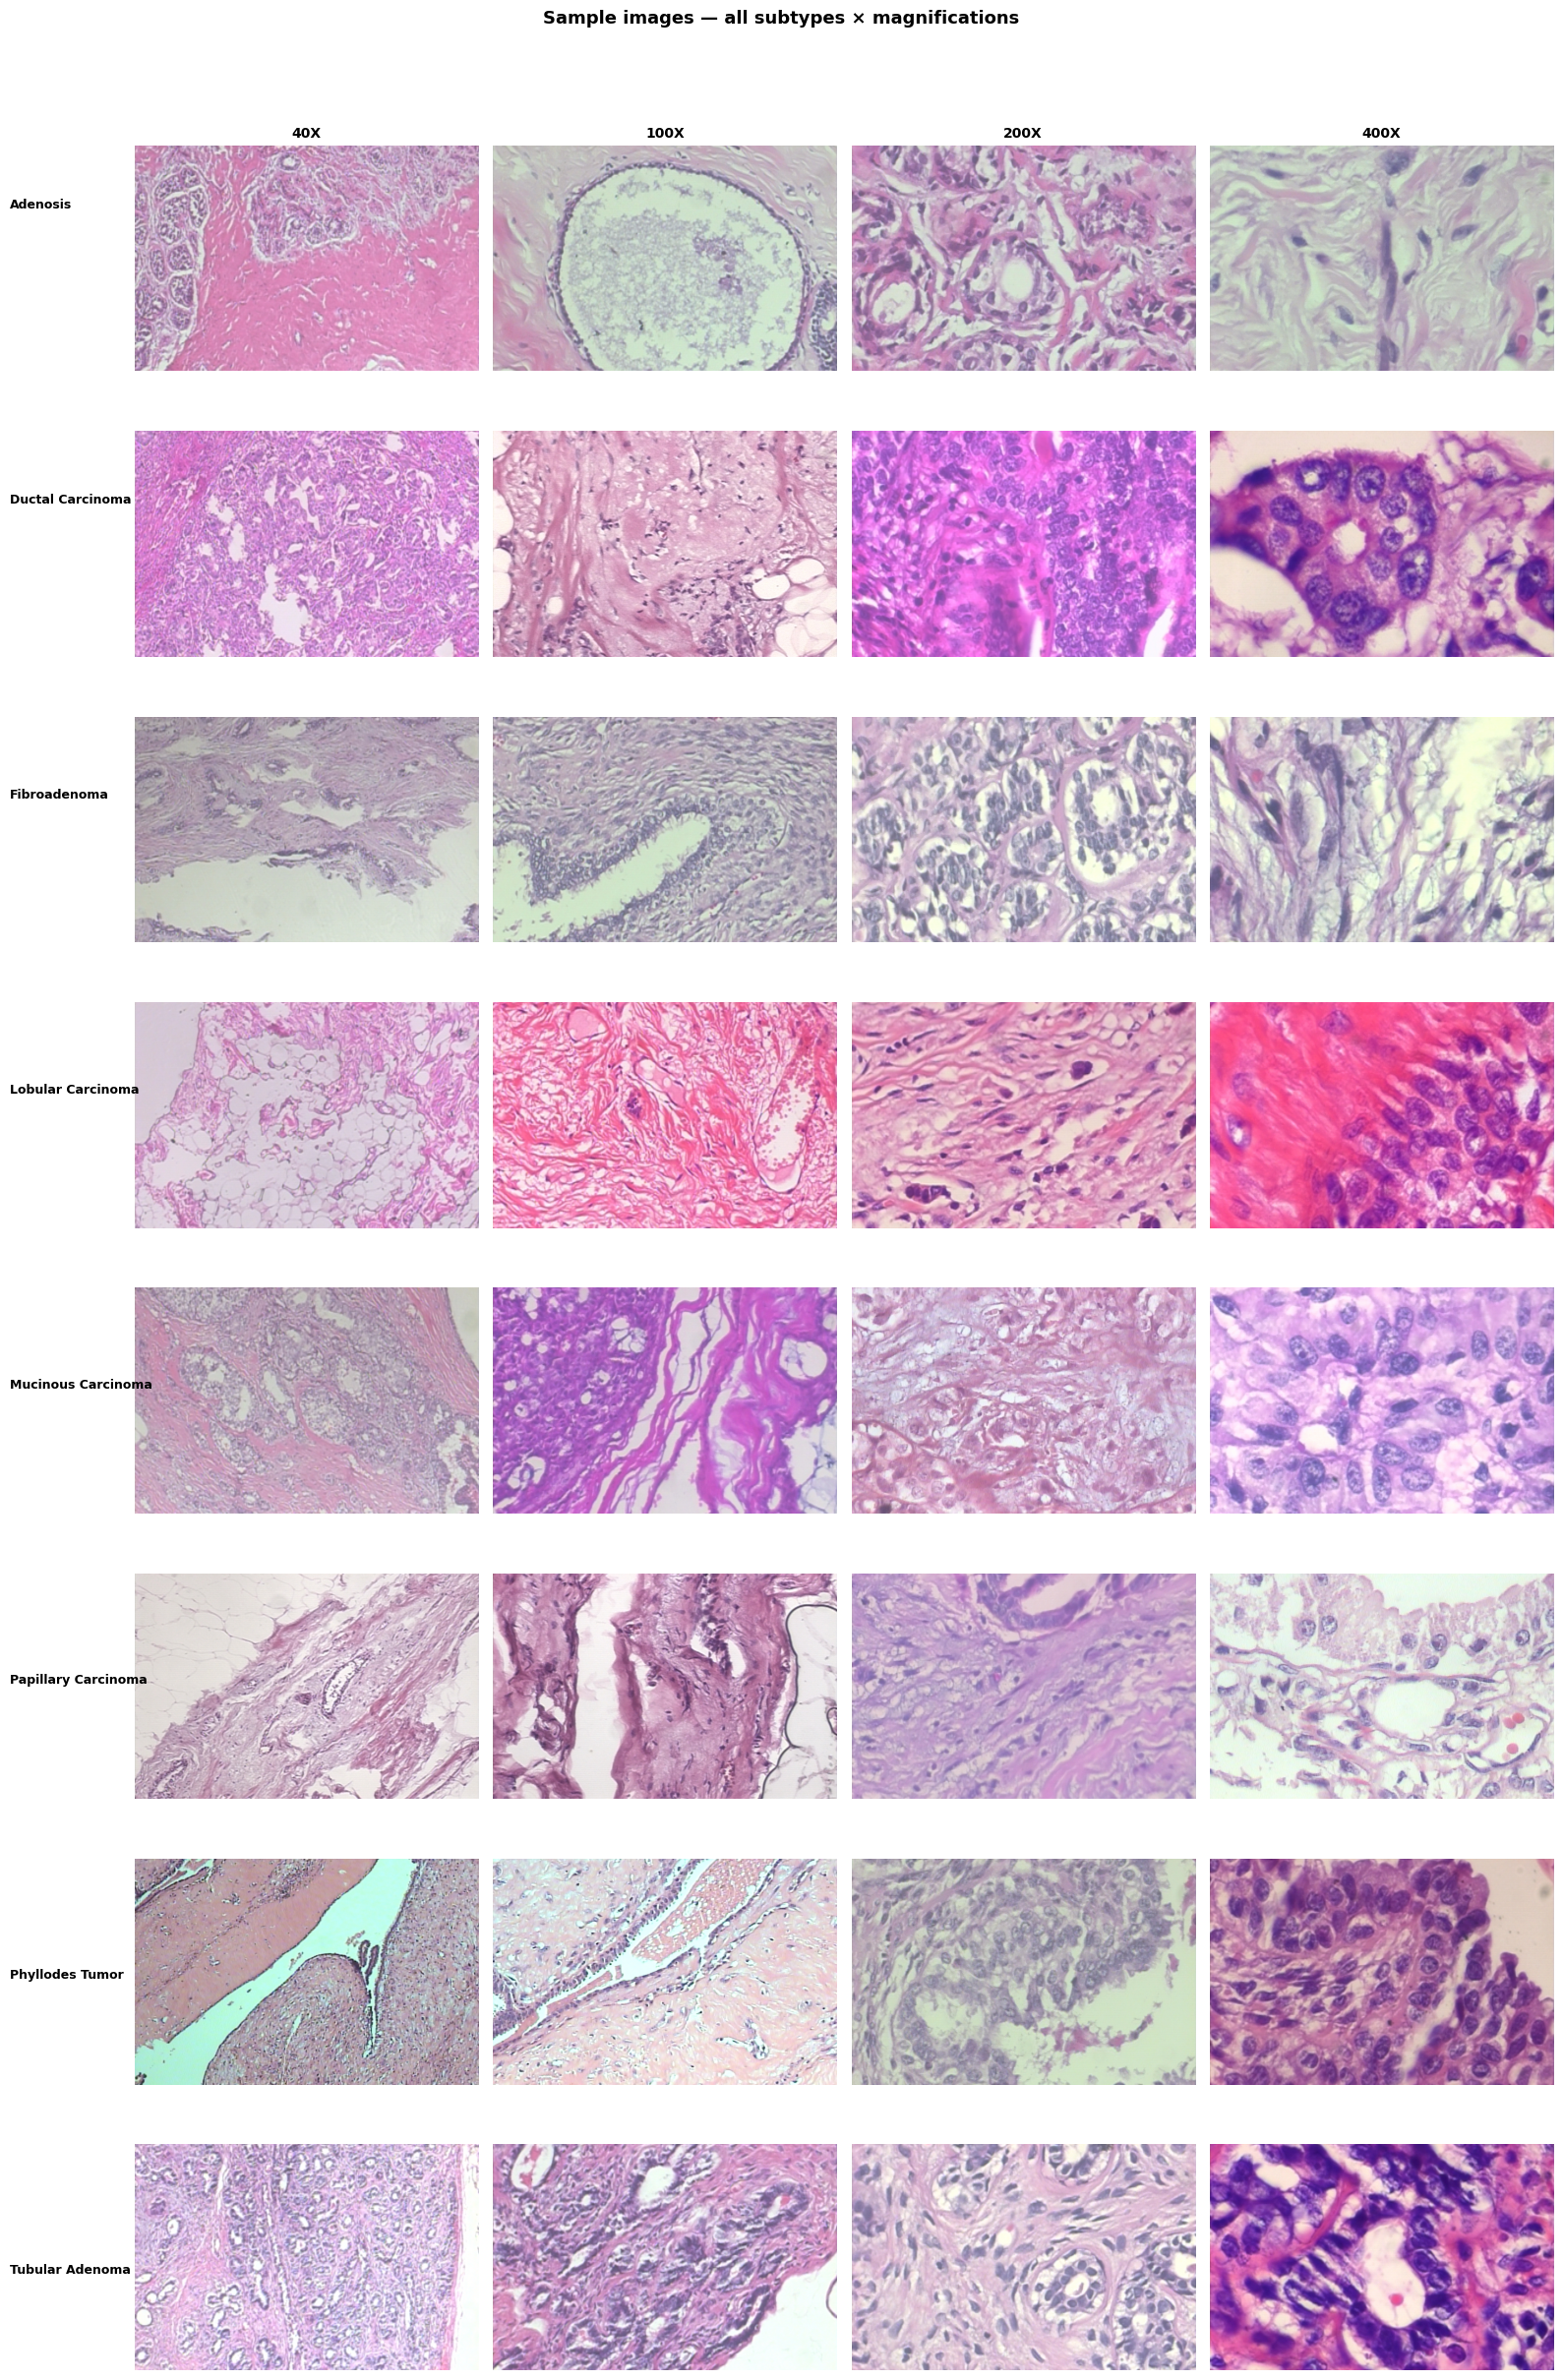

In [4]:
#code
#Cell 4 — sample image grid (all subtypes × magnifications)
fig, axes = plt.subplots(8, 4, figsize=(16, 24))
mags = ['40X', '100X', '200X', '400X']

for row, subtype in enumerate(subtypes):
    for col, mag in enumerate(mags):
        subset = df[(df['subtype'] == subtype) & (df['magnification'] == mag)]
        sample_path = subset.sample(1).iloc[0]['path']
        img = Image.open(sample_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(mag, fontsize=10, fontweight='bold')

    # add subtype label as text on the left of each row
    fig.text(
        0.01, 1 - (row + 0.5) / 8,
        subtype.replace('_', ' ').title(),
        ha='left', va='center',
        fontsize=9, fontweight='bold',
        transform=fig.transFigure
    )

plt.suptitle('Sample images — all subtypes × magnifications',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0.08, 0, 1, 1])  # leave space on left for labels
plt.savefig('/kaggle/working/figures/sample_grid.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
#code
#Cell 6 — save splits (notebook 2 will load these)
from sklearn.model_selection import train_test_split

patients = df['patient'].unique()
train_pts, temp_pts = train_test_split(patients, test_size=0.3, random_state=42)
val_pts,   test_pts = train_test_split(temp_pts,  test_size=0.5, random_state=42)

df['split'] = 'train'
df.loc[df['patient'].isin(val_pts),  'split'] = 'val'
df.loc[df['patient'].isin(test_pts), 'split'] = 'test'

# rest of cell 6 continues below...
df.to_csv('/kaggle/working/splits/full_df.csv', index=False)
# ... etc
df.to_csv('/kaggle/working/splits/full_df.csv', index=False)

for split in ['train', 'val', 'test']:
    df[df['split'] == split].to_csv(
        f'/kaggle/working/splits/{split}.csv', index=False
    )

print("Saved:")
for f in os.listdir('/kaggle/working/splits'):
    print(" ", f)

# also save the subtype mapping so all notebooks use the same labels
pd.DataFrame(list(subtype2idx.items()),
             columns=['subtype', 'label']).to_csv(
    '/kaggle/working/splits/subtype_mapping.csv', index=False
)
print("\nNotebook 1 complete. Commit this notebook to pass splits to notebook 2.")

Saved:
  full_df.csv
  test.csv
  val.csv
  train.csv

Notebook 1 complete. Commit this notebook to pass splits to notebook 2.


## Train / validation / test split

Splits were performed at the **patient level** to prevent data leakage — ensuring 
no patient's tissue appears in both training and test sets. This is critical in 
medical imaging, where image-level splits artificially inflate test accuracy.

| Split | Patients | Images (approx) |
|-------|----------|-----------------|
| Train | 70%      | ~5,536          |
| Val   | 15%      | ~1,187          |
| Test  | 15%      | ~1,187          |

Split CSVs saved to `/kaggle/working/splits/` and will be loaded by all subsequent notebooks.